# Multi-Agent Collaboration



In this pattern, different agents or nodes handle different roles such as researcher, planner, and writer.



## Stack

- Framework: LangGraph multi-node collaboration

- LLM: local Ollama via `ChatOllama(model="llama3.1:latest")`

- Pattern goal: role separation



## When to use it

- Roles are naturally separable

- One agent would otherwise become overloaded

## Architecture



```mermaid

graph LR

    T[Topic] --> R[Research Agent]

    R --> P[Planning Agent]

    P --> W[Writing Agent]

    W --> O[Final Draft]

```

In [ ]:
from visual_diagram_helper import render_svg_flow



nodes = [

    ("topic", "Topic", 60, 170, "#bfdbfe"),

    ("research", "Research Agent", 290, 80, "#bbf7d0"),

    ("planner", "Planner Agent", 520, 170, "#fde68a"),

    ("writer", "Writer Agent", 750, 260, "#fecaca"),

    ("output", "Final Draft", 980, 170, "#ddd6fe"),

]

edges = [

    ("topic", "research"),

    ("research", "planner"),

    ("planner", "writer"),

    ("writer", "output"),

]



render_svg_flow("Multi-Agent Visual Architecture", nodes, edges, width=1220, height=420)

In [ ]:
# Reload shared helpers so any edits to agent_patterns_common.py take effect

# without needing to restart the kernel.

import importlib

import agent_patterns_common



importlib.reload(agent_patterns_common)

print("agent_patterns_common reloaded.")

### Multi-Agent Collaboration State Graph

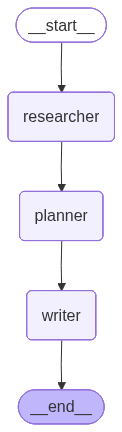

{"level": "INFO", "event_type": "researcher_start", "topic": "AI agent design patterns"}
{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "Return EXACTLY 3 research bullets.\nEach bullet must start with '- '.\nTopic: AI a"}
{"level": "INFO", "event_type": "llm_invoke_success", "attempt": 1}
{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "Create a deterministic outline with EXACTLY 3 numbered lines.\nResearch notes:\nHe"}
{"level": "INFO", "event_type": "llm_invoke_success", "attempt": 1}
{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "Write EXACTLY 4 bullet points as the final draft.\nEach bullet starts with '- '.\n"}
{"level": "INFO", "event_type": "llm_invoke_success", "attempt": 1}
{"level": "INFO", "event_type": "writer_complete", "topic": "AI agent design patterns"}


{'topic': 'AI agent design patterns',
 'research_notes': "Here are exactly 3 research bullets on AI agent design patterns, each starting with '- ':\n\n- **Model-View-Controller (MVC) Pattern**: This pattern separates the AI agent's logic into three interconnected components: Model (data and business logic), View (user interface), and Controller (coordinates interactions between Model and View). Research has shown that MVC can improve maintainability, scalability, and reusability of AI agents in complex environments [1].\n\n- **Observer Pattern**: This pattern allows the AI agent to notify other components or systems when its internal state changes. By decoupling the observer from the observed subject, the AI agent can efficiently manage multiple dependencies and interactions with external systems, enhancing flexibility and adaptability [2].\n\n- **Strategy Pattern**: This pattern enables the AI agent to define a family of algorithms (strategies) that can be used interchangeably without

In [ ]:
from langgraph.graph import END, START, StateGraph



from agent_pattern_states import CollaborationState

from agent_patterns_common import (

    append_history,

    build_checkpointer,

    get_local_llm,

    invoke_with_retry,

    log_event,

    render_state_graph,

)





llm = get_local_llm()





def researcher_node(state: CollaborationState) -> CollaborationState:

    log_event("info", "researcher_start", topic=state["topic"])

    prompt = (

        "Return EXACTLY 3 research bullets.\n"

        "Each bullet must start with '- '.\n"

        f"Topic: {state['topic']}"

    )

    notes = invoke_with_retry(llm, prompt)

    return {

        "research_notes": notes,

        "history": append_history(state.get("history"), "Research notes created"),

    }





def planner_node(state: CollaborationState) -> CollaborationState:

    prompt = (

        "Create a deterministic outline with EXACTLY 3 numbered lines.\n"

        f"Research notes:\n{state['research_notes']}"

    )

    outline = invoke_with_retry(llm, prompt)

    return {

        "outline": outline,

        "history": append_history(state["history"], "Outline generated"),

    }





def writer_node(state: CollaborationState) -> CollaborationState:

    prompt = (

        "Write EXACTLY 4 bullet points as the final draft.\n"

        "Each bullet starts with '- '.\n"

        f"Topic: {state['topic']}\n"

        f"Research notes: {state['research_notes']}\n"

        f"Outline: {state['outline']}\n"

        f"History: {state['history']}"

    )

    draft = invoke_with_retry(llm, prompt)

    log_event("info", "writer_complete", topic=state["topic"])

    return {

        "draft": draft,

        "history": append_history(state["history"], "Final draft written"),

    }





builder = StateGraph(CollaborationState)

builder.add_node("researcher", researcher_node)

builder.add_node("planner", planner_node)

builder.add_node("writer", writer_node)

builder.add_edge(START, "researcher")

builder.add_edge("researcher", "planner")

builder.add_edge("planner", "writer")

builder.add_edge("writer", END)



graph = builder.compile(checkpointer=build_checkpointer())

render_state_graph(graph, "Multi-Agent Collaboration State Graph")



result = graph.invoke(

    {

        "topic": "AI agent design patterns",

        "research_notes": "",

        "outline": "",

        "draft": "",

        "history": [],

    },

    config={"configurable": {"thread_id": "multi-agent-demo"}},

)



result

## Design insight



Multi-agent design is useful when roles are genuinely distinct. If the roles do not create a clear boundary, the extra coordination cost is usually not worth it.